using cpu


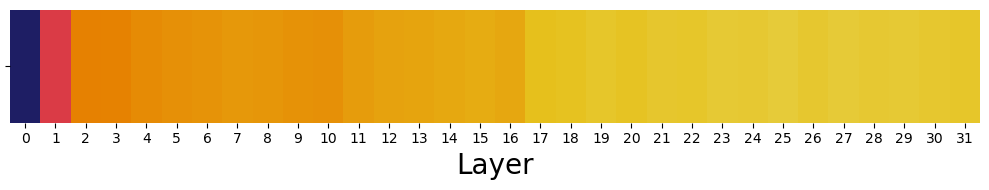

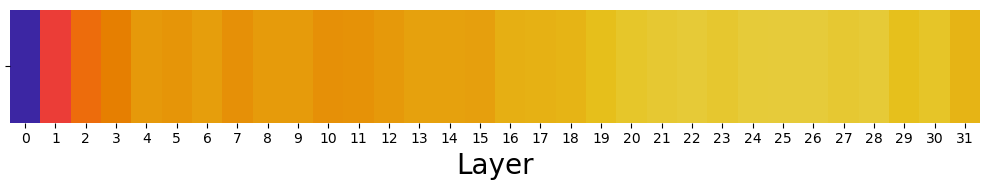

In [12]:
from track_block_activations import get_acts
from block_drop import *
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import os
import numpy as np
import torch.nn as nn
from numpy.linalg import norm
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from evaluation.effectiveness import *
from evaluation.self_explanation import eval_self_explanation
import json
import pandas as pd
from datasets import load_dataset
    
n_samples = 8
LMs=['meta-llama/Llama-2-7b-hf',"mistralai/Mistral-7B-v0.1"]

device = torch.device("cpu")
if torch.cuda.is_available():
    print(torch.cuda.device_count())
    device = torch.device("cuda:0")
    print("using gpu")
else:
    print("using cpu")




def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap


for model_name in LMs:
    path_unpruned_model = "./saved_models/unpruned/" + model_name
    
    base_results_path = "./acts/activations/"+ model_name+"/"

    scores = np.load(base_results_path+"final_scores.npy")
        
    ys = [1-out for out in scores]
    
    
    tmp = "./results/plots/intro/"+"/".join(model_name.split("/")[:-1])
    if not os.path.exists(tmp):
        os.makedirs(tmp)
    
    xs = list(range(len(scores)))
    

    plt.figure(figsize=(10, 2))
    cmap = plt.get_cmap('CMRmap_r')
    labels = [""]
    df_cm = pd.DataFrame([ys], index = labels)

    sns.heatmap(df_cm, cmap=truncate_colormap(cmap, 0.2, 0.9), vmin=0, vmax=0.3, cbar=False)
    plt.xlabel("Layer", fontsize=20)
    #plt.ylabel("Importance")

    plt.tight_layout()
    plt.savefig("./results/plots/intro/"+ model_name+"_scores_heatmap.pdf", dpi=600, bbox_inches="tight")
    plt.show()
    
    
    